In [1]:
%config Completer.use_jedi = False

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import warnings
import math
import numpy as np

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'

org_data = pd.read_csv('2010_2022_count.csv')
org_data = org_data[['REG_DTIME', 'h_dong', 'count', 'pops', 'windspd' , 'humid' , 'temp', 'precip_form', 'precip', 'isHoliday']]
dongs = org_data['h_dong'].unique()

In [3]:
# functions
def moving_average_com(df, unit):
    '''
    training datset에 ewma를 적용하는 함수 
    '''
    ret_df = pd.DataFrame()
    max_value = df['count'].max()
    # forward df
    for dong in df['h_dong'].unique():
        dong_df = df[df['h_dong'] == dong]
        inv_dong_df = df[df['h_dong'] == dong][::-1]
        dong_df['count'] = dong_df['count'].ewm(com = unit).mean()
        for_ewma = dong_df['count'].ewm(com = unit).mean()
        back_ewma = inv_dong_df['count'].ewm(com = unit).mean()

        ewma = (for_ewma + back_ewma)/2 
        df['count'][dong_df.index] = ewma 
    df['count'] = df['count']  /  df['count'].max() * (max_value+2)
    
    #print(max_value , df['count'].max())
    return df


def moving_average_span(df, unit):
    '''
    training datset에 ewma를 적용하는 함수 
    '''
    ret_df = pd.DataFrame()
    max_value = df['count'].max()
    # forward df
    for dong in df['h_dong'].unique():
        dong_df = df[df['h_dong'] == dong]
        inv_dong_df = df[df['h_dong'] == dong][::-1]
        dong_df['count'] = dong_df['count'].ewm(span = unit).mean()
        for_ewma = dong_df['count'].ewm(span = unit).mean()
        back_ewma = inv_dong_df['count'].ewm(span = unit).mean()

        ewma = (for_ewma + back_ewma)/2 
        df['count'][dong_df.index] = ewma 
    df['count'] = df['count']  /  df['count'].max() * (max_value+2)
    
    #print(max_value , df['count'].max())
    return df

def moving_average_halflife(df, unit):
    '''
    training datset에 ewma를 적용하는 함수 
    '''
    ret_df = pd.DataFrame()
    max_value = df['count'].max()
    # forward df
    for dong in df['h_dong'].unique():
        dong_df = df[df['h_dong'] == dong]
        inv_dong_df = df[df['h_dong'] == dong][::-1]
        dong_df['count'] = dong_df['count'].ewm(halflife = unit).mean()
        for_ewma = dong_df['count'].ewm(halflife = unit).mean()
        back_ewma = inv_dong_df['count'].ewm(halflife = unit).mean()

        ewma = (for_ewma + back_ewma)/2 
        df['count'][dong_df.index] = ewma 
    df['count'] = df['count']  /  df['count'].max() * (max_value+2)
    
    #print(max_value , df['count'].max())
    return df


def moving_average_alpha(df: pd.DataFrame, unit: int):
    '''
    training datset에 ewma를 적용하는 함수 
    '''
    ret_df = pd.DataFrame()
    max_value = df['count'].max()
    # forward df
    for dong in df['h_dong'].unique():
        dong_df = df[df['h_dong'] == dong]
        inv_dong_df = df[df['h_dong'] == dong][::-1]
        dong_df['count'] = dong_df['count'].ewm(alpha = unit).mean()
        for_ewma = dong_df['count'].ewm(alpha = unit).mean()
        back_ewma = inv_dong_df['count'].ewm(alpha = unit).mean()

        ewma = (for_ewma + back_ewma)/2 
        df['count'][dong_df.index] = ewma 
    df['count'] = df['count']  /  df['count'].max() * (max_value)
    
    #print(max_value , df['count'].max())
    return df


def dong_actual(mv_data,start , end , ewma , option):
    dt = pd.date_range(start, end , freq = '1h').astype(str)

    for dong in dongs[14:15]:
        plt.figure(figsize=(12,4))
        dong_df = mv_data[mv_data['h_dong'] == dong]
        time_df = dong_df[dong_df['REG_DTIME'].isin(dt)]
        time_df.reset_index(inplace=True)

        org_dong_df = org_data[org_data['h_dong'] == dong]
        org_time_df = org_dong_df[org_dong_df['REG_DTIME'].isin(dt)]
        org_time_df.reset_index(inplace=True)
        plt.plot(org_time_df.index, time_df['count'] , label=f'{dong} ewma' ,alpha=0.8 )
        plt.plot(org_time_df.index, org_time_df['count'] , label=f'{dong} orignal', alpha = 0.5)
        
        plt.title(f'{dong} actual & {dong} , {option}')
        plt.legend()

# 원하는 기간 설정
start = '2022/1/1'
end = '2022/2/28'

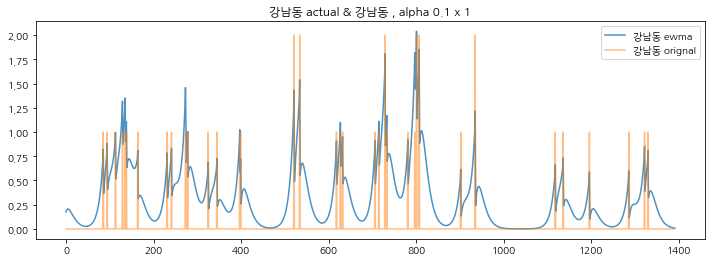

In [9]:
ewma = 0.1
mv_data = org_data.copy(deep=True)
for time in range(1):
    mv_data = moving_average_alpha(mv_data,ewma)
xyz = dong_actual(mv_data,start, end, ewma, f'alpha {ewma} x {time+1}')
mv_data.to_csv('alpha_01.csv')

# result plot

In [5]:
# 원하는 기간 설정
start = '2021/1/1'
end = '2021/2/28'

##  alpha iter 1

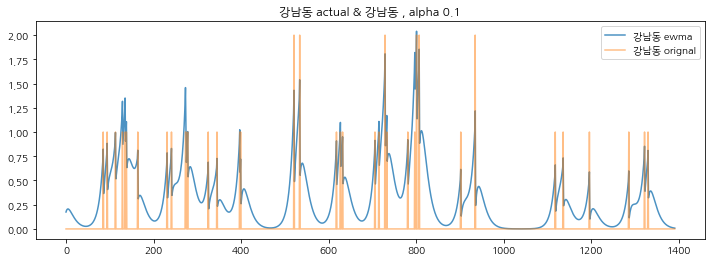

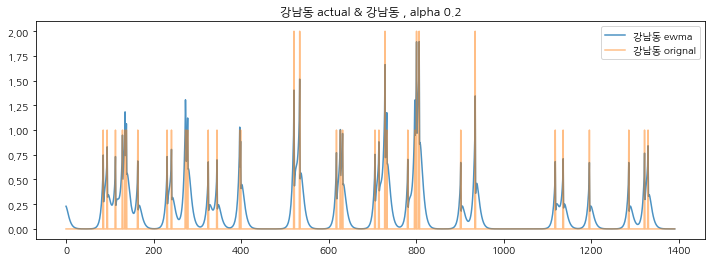

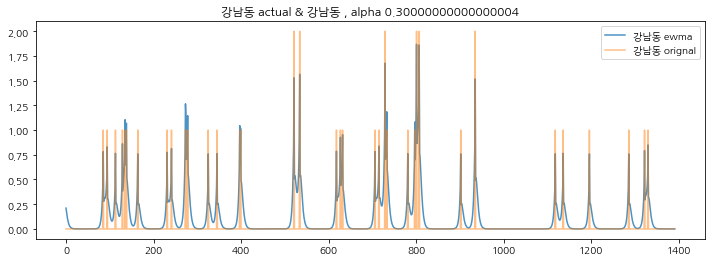

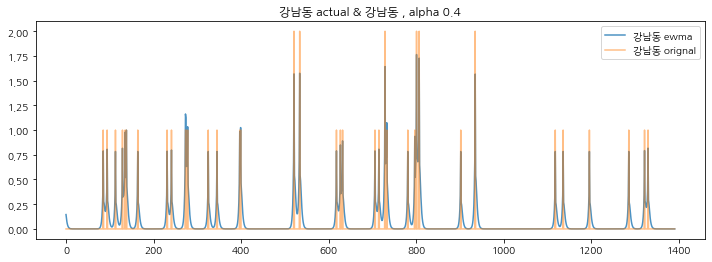

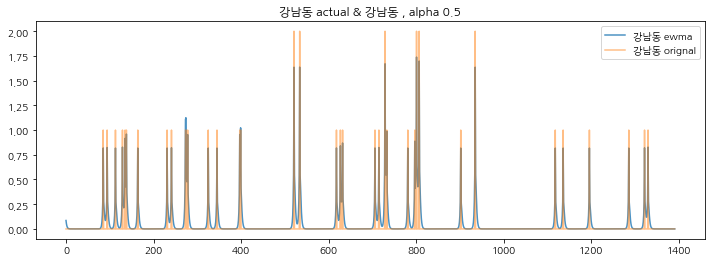

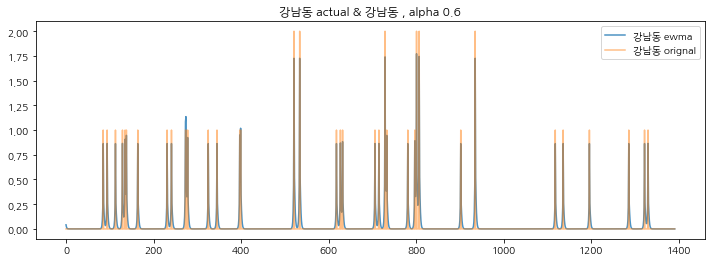

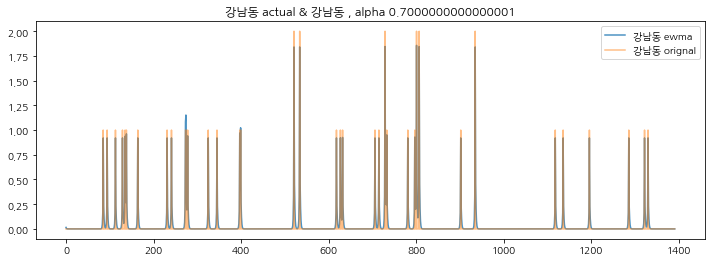

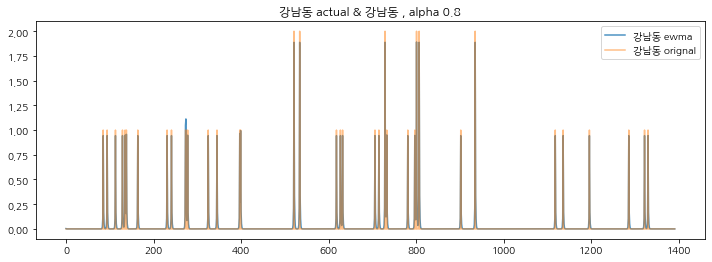

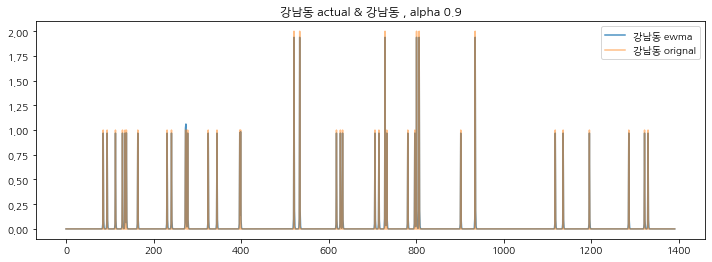

In [20]:
# alpha
#mv_data = org_data.copy(deep=True)
for i , ewma  in enumerate(np.arange(0.1, 1, 0.1)):
    mv_data = org_data.copy(deep=True)
    mv_data = moving_average_alpha(mv_data,ewma)
    dong_actual(mv_data,start, end, ewma, f'alpha {ewma}')
    mv_data.to_csv(f'./alpha/0{i+1}.csv')
    

## alphat iter2

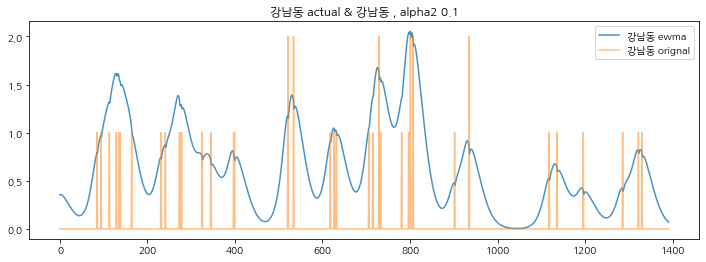

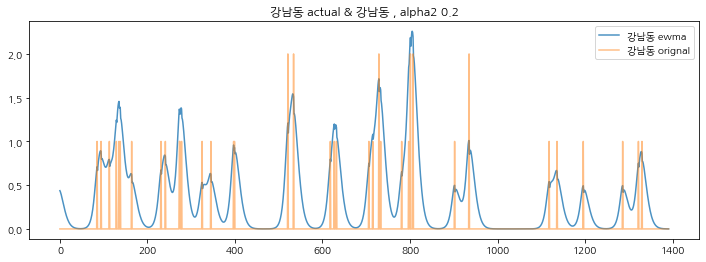

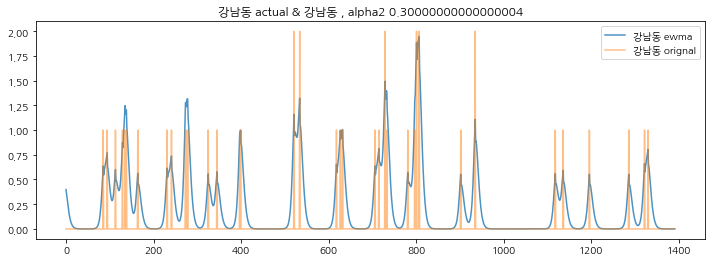

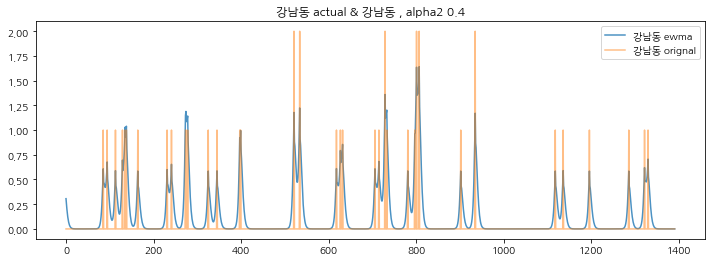

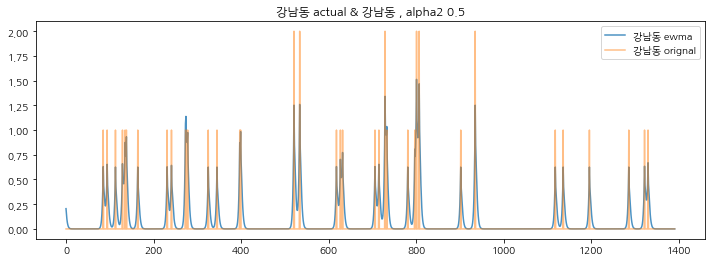

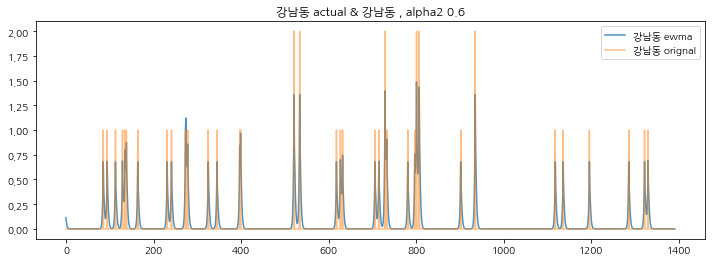

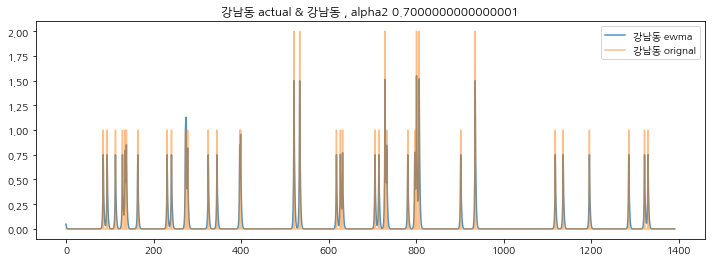

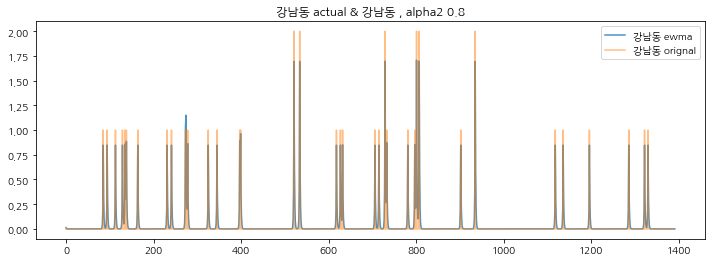

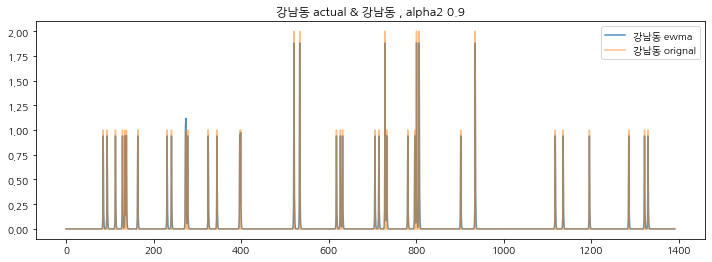

In [4]:
# alpha
#mv_data = org_data.copy(deep=True)
for i , ewma  in enumerate(np.arange(0.1, 1, 0.1)):
    mv_data = org_data.copy(deep=True)
    mv_data = moving_average_alpha(mv_data,ewma)
    mv_data = moving_average_alpha(mv_data,ewma)
    dong_actual(mv_data,start, end, ewma, f'alpha2 {ewma}')
    mv_data.to_csv(f'./alpha2/_0{i+1}.csv')
    

## COM iter 1

./com/1.csv
./com/2.csv
./com/3.csv
./com/4.csv
./com/5.csv
./com/6.csv


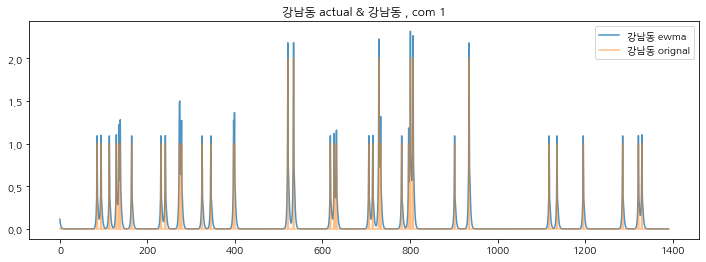

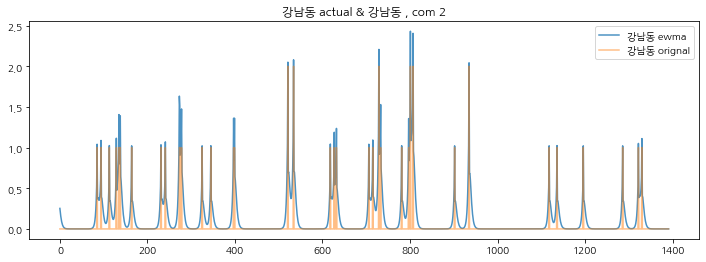

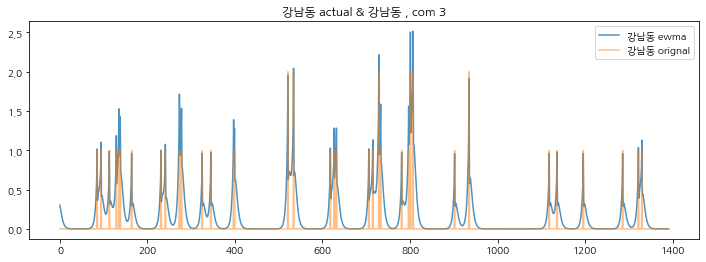

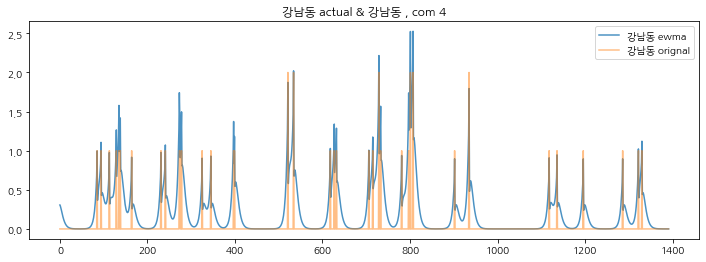

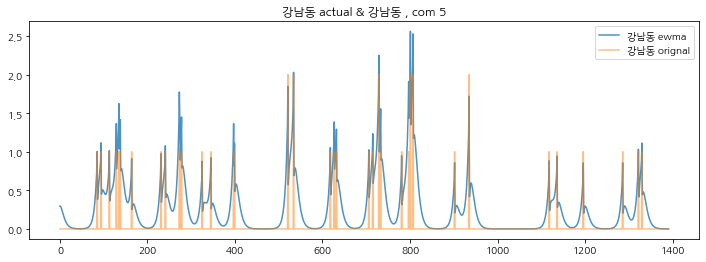

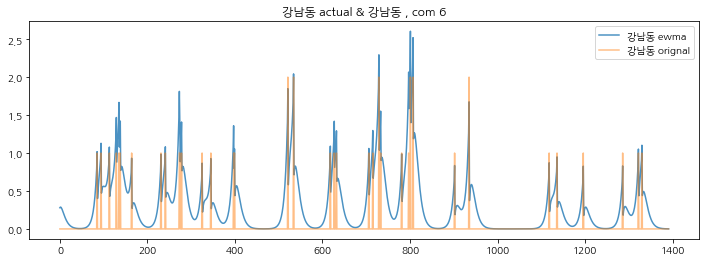

In [8]:
# com
#mv_data = org_data.copy(deep=True)
for ewma in range(1,7):
    mv_data = org_data.copy(deep=True)
    mv_data = moving_average_com(mv_data,ewma)
    dong_actual(mv_data,start, end, ewma, f'com {ewma}')
    mv_data.to_csv(f'./com/{ewma}.csv')
    print(f'./com/{ewma}.csv')

## COM iter 2

./com2/1.csv
./com2/2.csv
./com2/3.csv
./com2/4.csv
./com2/5.csv
./com2/6.csv


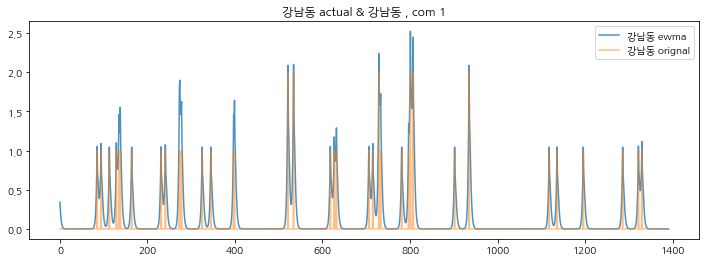

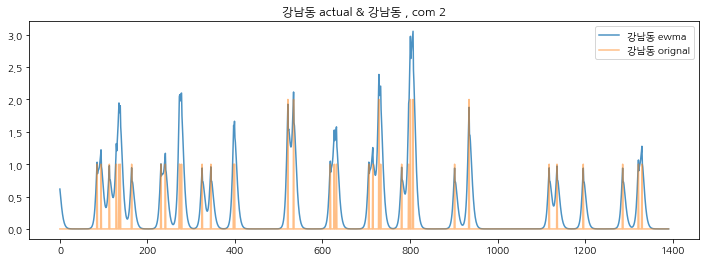

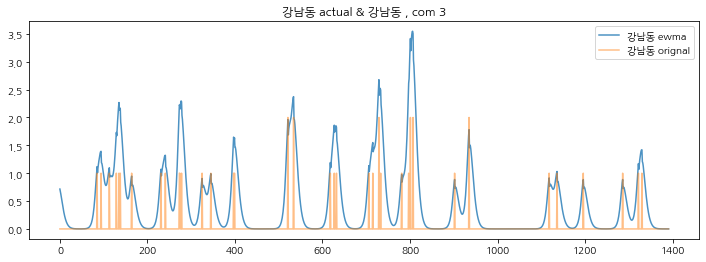

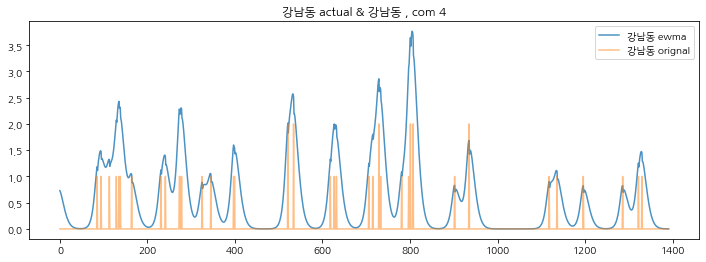

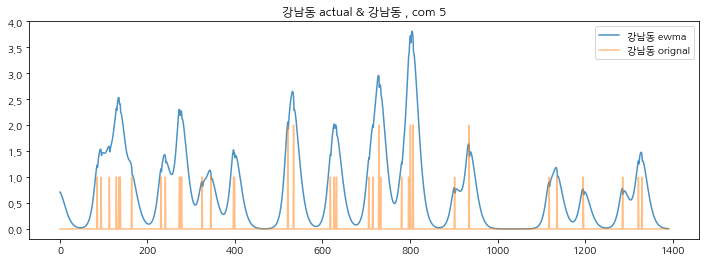

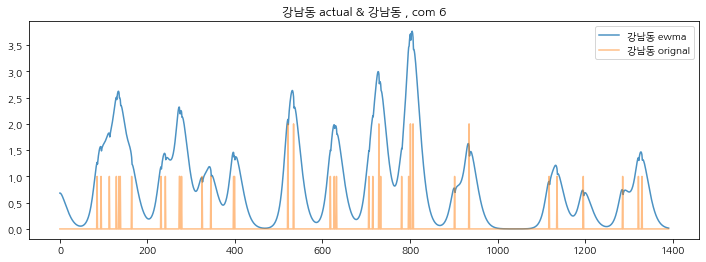

In [5]:
# com
#mv_data = org_data.copy(deep=True)
for ewma in range(1,7):
    mv_data = org_data.copy(deep=True)
    mv_data = moving_average_com(mv_data,ewma)
    mv_data = moving_average_com(mv_data,ewma)
    dong_actual(mv_data,start, end, ewma, f'com {ewma}')
    mv_data.to_csv(f'./com2/{ewma}.csv')
    print(f'./com2/{ewma}.csv')

## span iter1

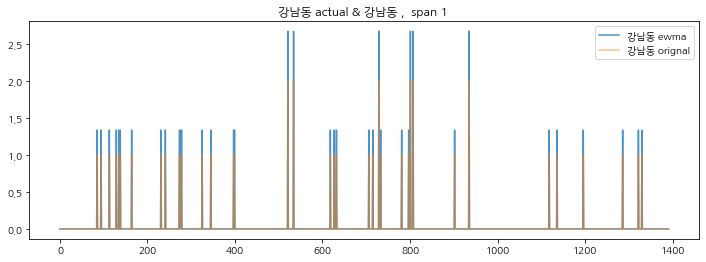

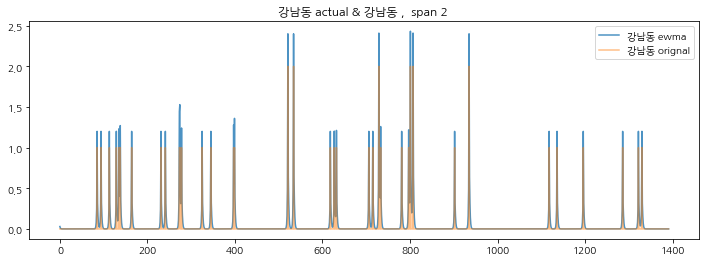

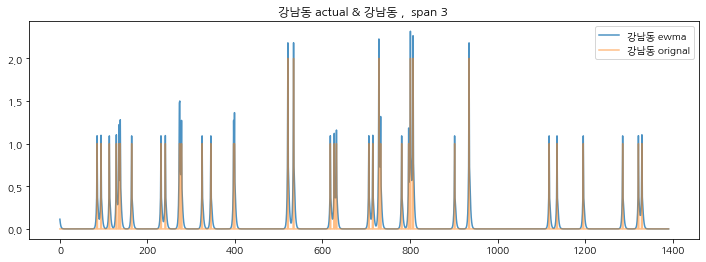

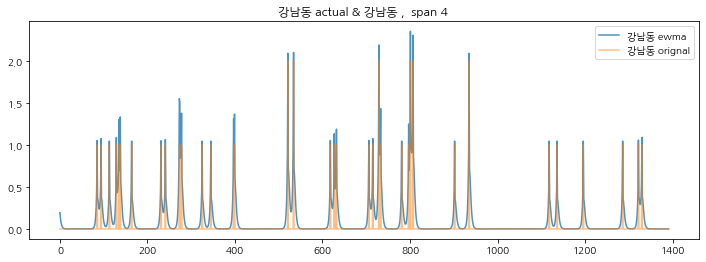

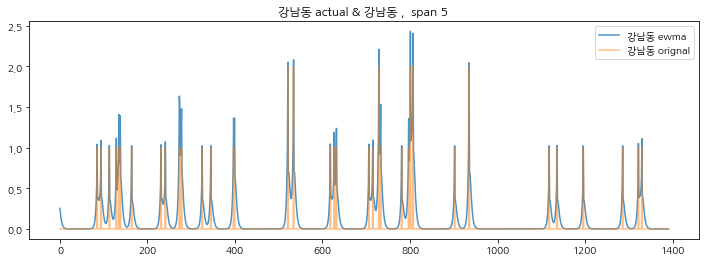

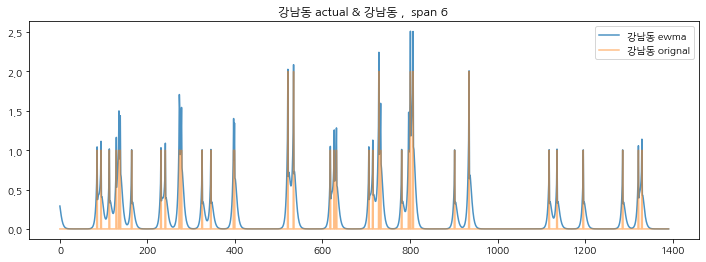

In [13]:
# span
#mv_data = org_data.copy(deep=True)
for ewma in range(1,7):
    mv_data = org_data.copy(deep=True)
    mv_data = moving_average_span(mv_data,ewma)
    dong_actual(mv_data,start, end, ewma, f' span {ewma} ')
    mv_data.to_csv(f'./span/{ewma}.csv')
    #print(f'./span/{ewma}.csv')

## span iter2


./span2/1.csv
./span2/2.csv
./span2/3.csv
./span2/4.csv
./span2/5.csv
./span2/6.csv


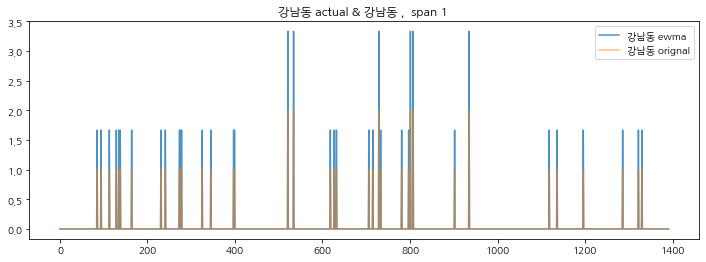

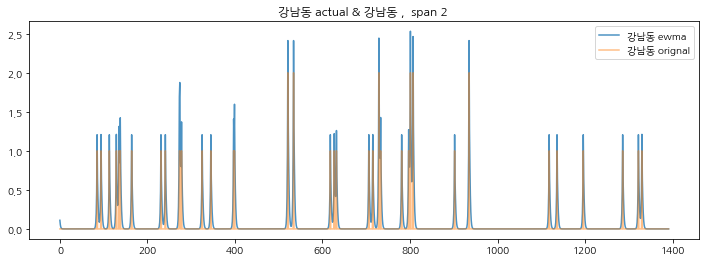

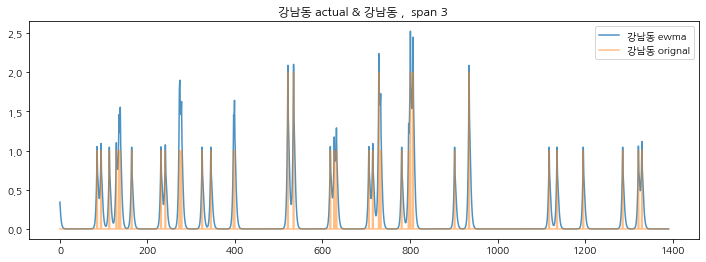

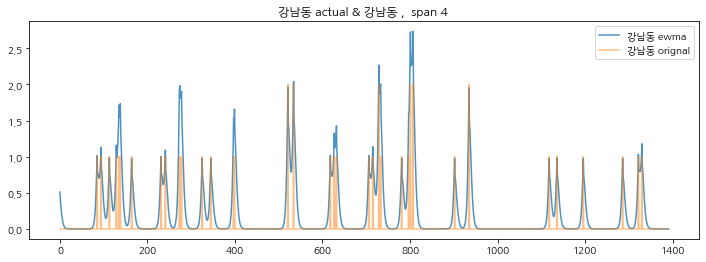

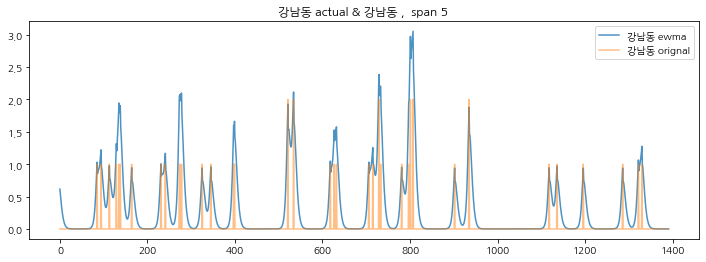

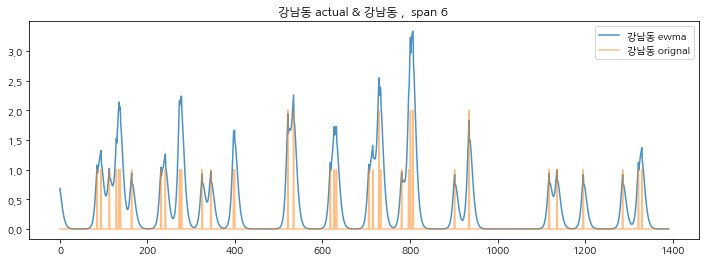

In [11]:
# span
#mv_data = org_data.copy(deep=True)
for ewma in range(1,7):
    mv_data = org_data.copy(deep=True)
    mv_data = moving_average_span(mv_data,ewma)
    mv_data = moving_average_span(mv_data,ewma)
    dong_actual(mv_data,start, end, ewma, f' span {ewma} ')
    mv_data.to_csv(f'./span2/{ewma}.csv')
    print(f'./span2/{ewma}.csv')

## halflife1

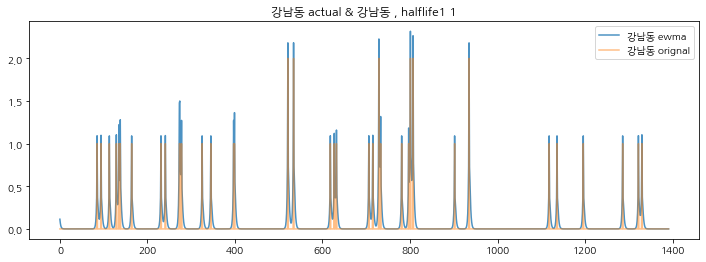

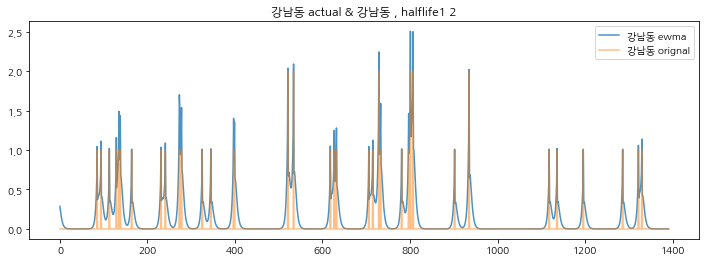

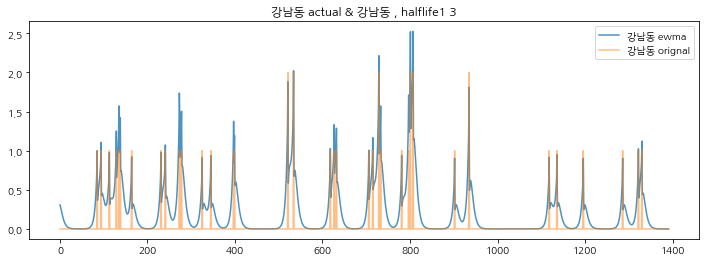

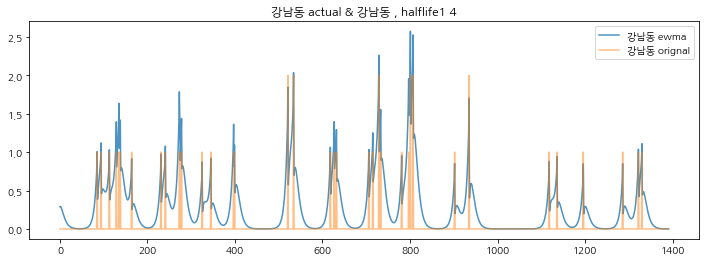

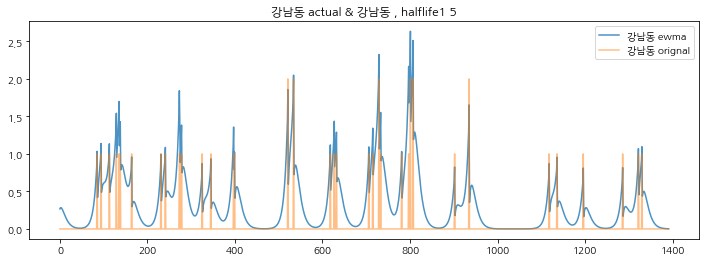

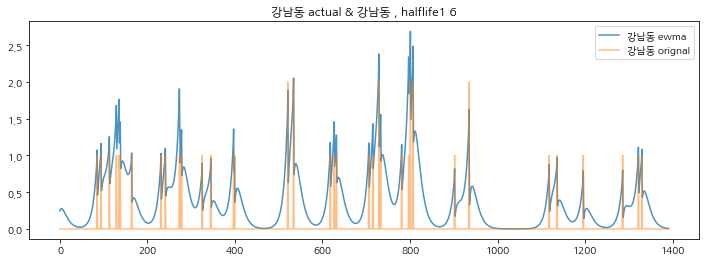

In [9]:
# halflife 
#mv_data = org_data.copy(deep=True)
mv_data = org_data.copy(deep=True)
for ewma in range(1,7):
    mv_data = org_data.copy(deep=True)
    mv_data = moving_average_halflife(mv_data,ewma)
    dong_actual(mv_data,start, end, ewma, f'halflife1 {ewma}')
    mv_data.to_csv(f'./halflife1/{ewma}.csv')

## halflife2

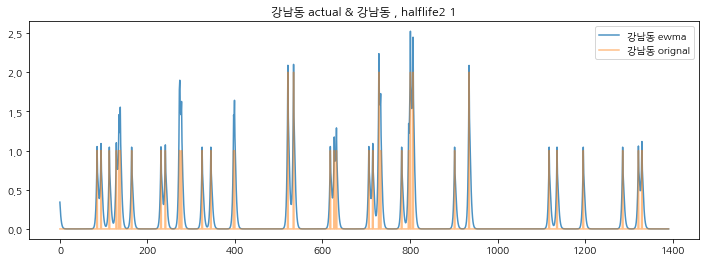

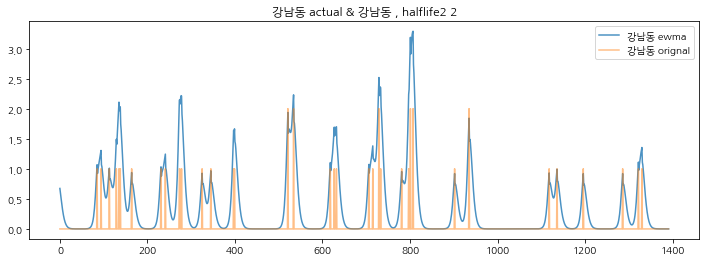

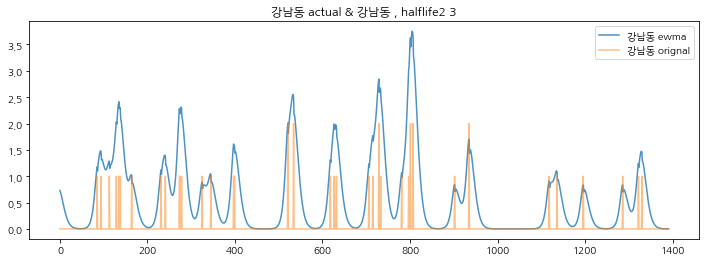

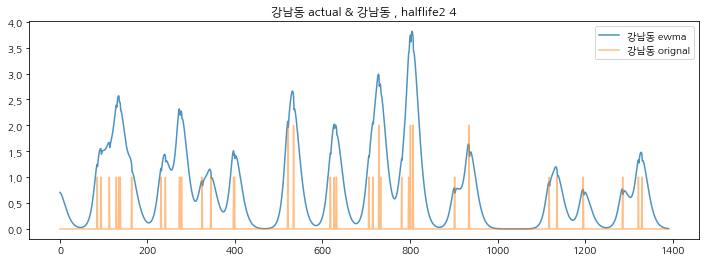

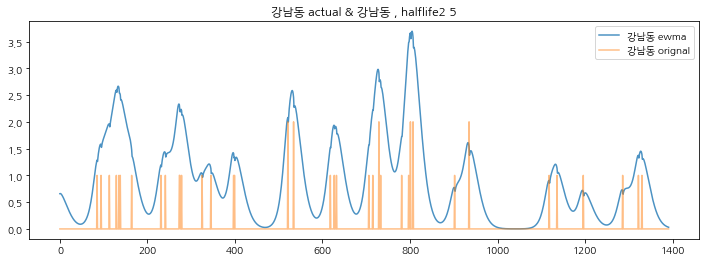

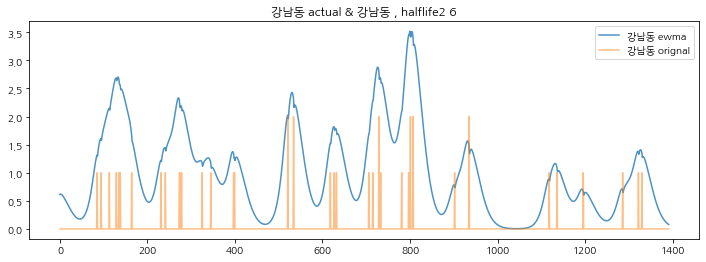

In [12]:
# halflife 
#mv_data = org_data.copy(deep=True)
mv_data = org_data.copy(deep=True)
for ewma in range(1,7):
    mv_data = org_data.copy(deep=True)
    mv_data = moving_average_halflife(mv_data,ewma)
    mv_data = moving_average_halflife(mv_data,ewma)
    dong_actual(mv_data,start, end, ewma, f'halflife2 {ewma}')
    mv_data.to_csv(f'./halflife2/{ewma}.csv')